In [1]:
import osmnx as ox
import networkx as nx
from osmnx.features import features_from_bbox
import geopandas as gpd
from geometric_utilities import *
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# 1) define your area of interest in lon/lat
west, south, east, north = 9.2257, 45.47162, 9.23768, 45.48537
bbox = (west, south, east, north)

# ────────────────
# 2) street network (all modes: drive+walk+bike…)
# ────────────────
G = ox.graph.graph_from_bbox(
    bbox=bbox,
    network_type="all",             # drive, walk, bike, all_public, etc.
)  # multiDiGraph of every way in bbox :contentReference[oaicite:0]{index=0}
nodes, edges = ox.graph_to_gdfs(G)

# ────────────────
# 3) vector features via Overpass
# ────────────────
# a) building footprints (+ any height/levels tags)
tags_buildings = {"building": True}
gdf_buildings = features_from_bbox(bbox, tags_buildings)  
# returns a GeoDataFrame multi-indexed by element type & OSM ID :contentReference[oaicite:1]{index=1}

# b) parks & town squares
tags_parks = {
    "leisure": ["park", "garden"],
    "amenity": ["town_square"]
}
gdf_parks = features_from_bbox(bbox, tags_parks)

# c) land-use areas (residential, commercial, industrial…)
tags_landuse = {"landuse": True}
gdf_landuse = features_from_bbox(bbox, tags_landuse)

# d) water bodies & waterways
tags_water = {"natural": ["water", "wetland"], "waterway": True}
gdf_water = features_from_bbox(bbox, tags_water)

# e) points of interest (amenities, shops, tourism…)
tags_pois = {"amenity": True, "shop": True, "tourism": True}
gdf_pois = features_from_bbox(bbox, tags_pois)

Street segments: 4942
Buildings: 1137
Parks/squares: 32


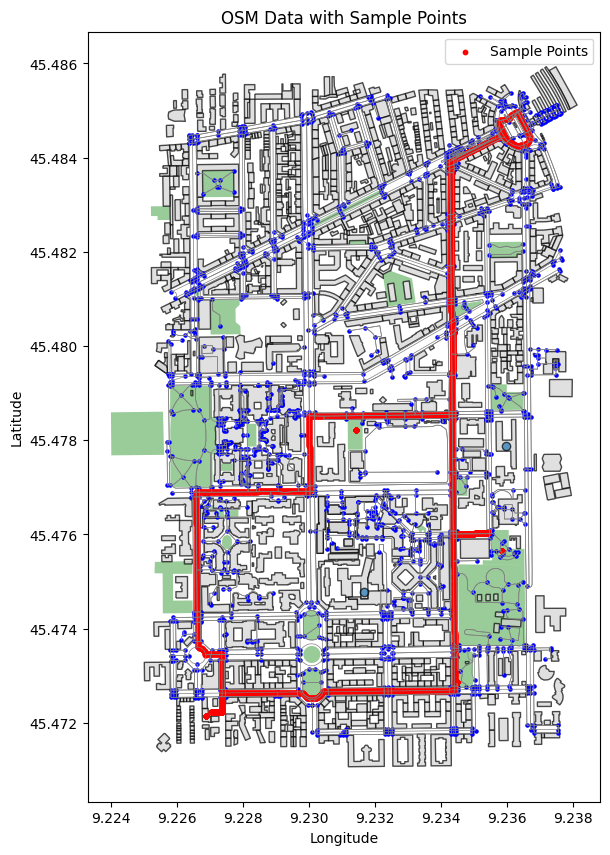

In [3]:
# ────────────────
# 4) quick inspection / plotting
# ────────────────

print("Street segments:", len(edges))
print("Buildings:", len(gdf_buildings))
print("Parks/squares:", len(gdf_parks))

# example plot
ax = edges.plot(linewidth=0.5, color="gray", figsize=(10, 10))
gdf_parks.plot(ax=ax, facecolor="green", alpha=0.4)
gdf_buildings.plot(ax=ax, facecolor="lightgray", edgecolor="black", alpha=0.7)
nodes.plot(ax=ax, color="blue", markersize=5)

# plot df.x and df.y in the same plot
df = pd.read_csv('../data/processed_data/S1CO2-approx-coordinates.csv')
ax.scatter(df.x, df.y, color='red', s=10, label='Sample Points')
ax.set_title("OSM Data with Sample Points")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.show()


In [4]:
df['close2park'] = df.apply(lambda row: is_close_to_park(gdf_parks, Point(row.x, row.y)), axis=1).astype(int)

In [5]:
df['indoor'] = df.apply(lambda row: is_indoor(gdf_buildings, Point(row.x, row.y)), axis=1).astype(int)

In [11]:
nodes[~nodes["highway"].isna()]

,y,x,street_count,junction,highway,railway,geometry
osmid,,,,,,,
175969702,45.484393,9.226474,4,NaN,traffic_signals,NaN,POINT (9.22647 45.48439)
175971288,45.484819,9.229931,4,NaN,traffic_signals,NaN,POINT (9.22993 45.48482)
206146662,45.481238,9.236586,4,NaN,traffic_signals,NaN,POINT (9.23659 45.48124)
206146811,45.480486,9.234315,4,NaN,traffic_signals,NaN,POINT (9.23431 45.48049)
206176492,45.481223,9.226526,4,NaN,traffic_signals,NaN,POINT (9.22653 45.48122)
...,...,...,...,...,...,...,...
11029669667,45.482909,9.230900,4,NaN,crossing,NaN,POINT (9.2309 45.48291)
11029669687,45.483007,9.231044,4,NaN,crossing,NaN,POINT (9.23104 45.48301)
11281688335,45.479185,9.228740,4,NaN,crossing,NaN,POINT (9.22874 45.47918)


In [13]:
nodes["railway"].unique()

array([nan, 'tram_crossing', 'train_station_entrance', 'subway_entrance',
       'tram_level_crossing'], dtype=object)

In [36]:
gdf_parks[~gdf_parks['leisure'].isna()]

geometry  \
element  id                                                              
relation 3585211     POLYGON ((9.23526 45.47536, 9.23526 45.47545, ...   
         6076967     POLYGON ((9.23312 45.48143, 9.23323 45.48092, ...   
         8066235     MULTIPOLYGON (((9.2258 45.47909, 9.22581 45.47...   
way      23727708    POLYGON ((9.2303 45.47383, 9.23031 45.47386, 9...   
         23727710    POLYGON ((9.23033 45.47262, 9.23037 45.47266, ...   
         24240361    POLYGON ((9.22739 45.47593, 9.22744 45.47597, ...   
         25260105    POLYGON ((9.23443 45.4806, 9.23521 45.48091, 9...   
         26014055    POLYGON ((9.2345 45.47274, 9.23498 45.47275, 9...   
         26144599    POLYGON ((9.22656 45.48107, 9.22669 45.48107, ...   
         64097525    POLYGON ((9.23452 45.47529, 9.23453 45.47536, ...   
         89684944    POLYGON ((9.2345 45.47682, 9.2348 45.47682, 9....   
         160136241   POLYGON ((9.22815 45.47787, 9.22841 45.47787, ...   
         261217286   POLYGON ((9.23033 45.47352, 9.23029 45.47357, ...   
         309099598   POLYGON ((9.23028 45.48051, 9.23041 45.48056, ...   
         330289178   POLYGON ((9.23548 45.48221, 9.23548 45.48214, ...   
         342787753   POLYGON ((9.23549 45.48188, 9.23631 45.48188, ...   
         345021968   POLYGON ((9.22522 45.48297, 9.22549 45.48297, ...   
         349543540   POLYGON ((9.23649 45.47903, 9.23599 45.47903, ...   
         405459505   POLYGON ((9.23123 45.48216, 9.23172 45.48217, ...   
         405462535   POLYGON ((9.22702 45.48036, 9.22702 45.48024, ...   
         534088624   POLYGON ((9.22734 45.47751, 9.22768 45.47751, ...   
         559105298   POLYGON ((9.23118 45.4778, 9.23163 45.4778, 9....   
         615908959   POLYGON ((9.23362 45.48281, 9.23359 45.48281, ...   
         615908960   POLYGON ((9.23362 45.48292, 9.23361 45.48292, ...   
         989371245   POLYGON ((9.22534 45.47542, 9.22533 45.47518, ...   
         1036681761  POLYGON ((9.22678 45.48372, 9.22678 45.48367, ...   
         1141445871      LINESTRING (9.228 45.47707, 9.22813 45.47707)   
         1187800689  POLYGON ((9.23217 45.48332, 9.23223 45.48324, ...   
         1231100670  POLYGON ((9.22721 45.47651, 9.22745 45.47651, ...   
         1231100671  POLYGON ((9.22755 45.47652, 9.22755 45.4765, 9...   
         1231100672  POLYGON ((9.227 45.47654, 9.2271 45.47654, 9.2...   
         1231100688  POLYGON ((9.23335 45.47605, 9.23342 45.47605, ...   

                    leisure                                        name  \
element  id                                                               
relation 3585211       park                                         NaN   
         6076967     garden                                         NaN   
         8066235       park                    Piazza Leonardo da Vinci   
way      23727708      park                     Giardino Luigi Cazzetta   
         23727710      park                     Giardino Luigi Cazzetta   
         24240361    garden                                         NaN   
         25260105    garden                      Parco pubblico Bassini   
         26014055      park                         Largo Oreste Murani   
         26144599    garden                                         NaN   
         64097525    garden  Orto botanico Universitario "Cascina Rosa"   
         89684944    garden                        Giardino Anna Carena   
         160136241   garden                                         NaN   
         261217286     park                                         NaN   
         309099598     park                                         NaN   
         330289178     park                                         NaN   
         342787753   garden                                         NaN   
         345021968     park                                         NaN   
         349543540     park                   Giardino Cesare Zavattini   
         405459505   garden                  

In [28]:
for i in gdf_buildings.columns:
    print(i)

geometry
building
name
amenity
denomination
level
religion
wheelchair
building:levels
healthcare
name:de
name:es
name:fr
roof:levels
roof:shape
wikidata
wikimedia_commons
wikipedia
contact:housenumber
contact:street
ref
alt_name
description
operator
roof:colour
website
email
name:en
name:it
phone
addr:housenumber
addr:street
building:material
loc_name
short_name
building:colour
height
ref:vatin
layer
isced:level
addr:city
addr:postcode
source
start_date
building:levels:underground
addr:unit
demolished:amenity
end_date
note
access
max_level
min_level
leisure
lit
sport
surface
internet_access
internet_access:fee
internet_access:ssid
opening_hours
ref:isil
bar
check_date
check_date:opening_hours
opening_hours:signed
payment:cash
payment:mastercard
payment:visa
shop
diet:vegetarian
indoor_seating
outdoor_seating
smoking
operator:wikidata
operator:wikipedia
operator:type
preschool
fax
office
material
roof:material
contact:phone
information
tourism
cuisine
indoor
building:prefabricated
depar

In [55]:
col = 'operator'
gdf_buildings[~gdf_buildings[col].isna()][col].unique()

array(['Università degli Studi di Milano', 'Università Statale di Milano',
       'Polizia Locale', 'Comune di Milano', 'TIM', 'AVIS', 'ATM'],
      dtype=object)

In [ ]:
# gdf_buildings['building] == industrial
# gdf_buildings['building:level] (average nearby building levels)

/tmp/ipykernel_57644/220869531.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


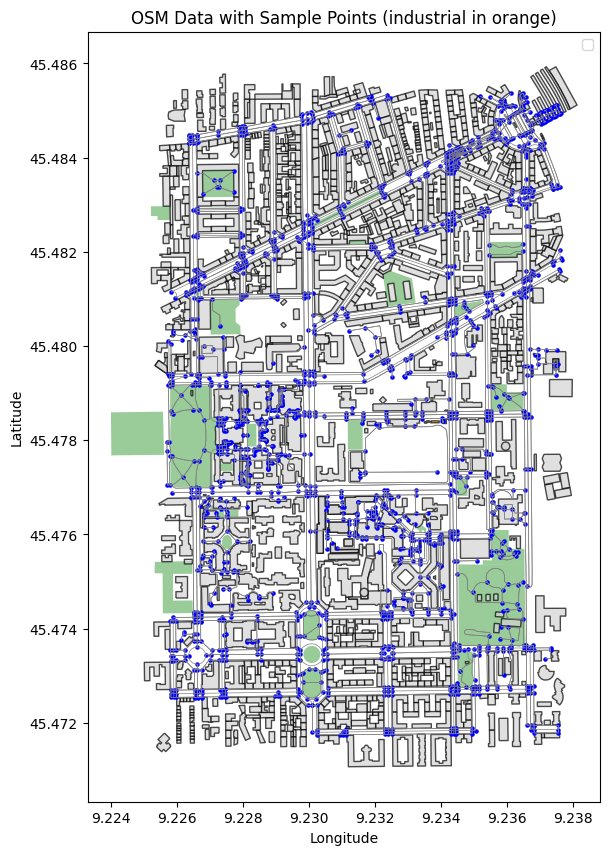

In [53]:
import matplotlib.pyplot as plt

# build a color list
building_colors = [
    "orange" if b == "bar" else "lightgray"
    for b in gdf_buildings["amenity"]
]

fig, ax = plt.subplots(figsize=(10, 10))

edges.plot(ax=ax, linewidth=0.5, color="gray")
gdf_parks.plot(ax=ax, facecolor="green", alpha=0.4)
# use our custom color list here:
gdf_buildings.plot(
    ax=ax,
    color=building_colors,
    edgecolor="black",
    alpha=0.7
)
nodes.plot(ax=ax, color="blue", markersize=5)

df = pd.read_csv('../data/processed_data/S1CO2-approx-coordinates.csv')
# ax.scatter(df.x, df.y, color='red', s=10, label='Sample Points')

ax.set_title("OSM Data with Sample Points (industrial in orange)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.show()
